# RT-IoT2022 Multi-Class IoT Attack Detection
### CSE 445 (Machine Learning) — Section 8


In [1]:
# 0. Install & import dependencies
!pip -q install ucimlrepo
!pip install matplotlib
%pip install seaborn
%pip install scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


## 1. Dataset Loading & Understanding

In [2]:
# Fetch the RT-IoT2022 dataset directly from the UCI ML Repository
from ucimlrepo import fetch_ucirepo

rt_iot2022 = fetch_ucirepo(id=942)

X_raw = rt_iot2022.data.features.copy()
y_raw = rt_iot2022.data.targets.copy()

# The target column may come back as a single-column DataFrame -> squeeze to a Series
if isinstance(y_raw, pd.DataFrame):
    target_col = y_raw.columns[0]
    y_raw = y_raw[target_col]

df = X_raw.copy()
df["target"] = y_raw.values

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(list(df.columns))


Dataset shape: (123117, 84)

Column names:
['id.orig_p', 'id.resp_p', 'proto', 'service', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count', 'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std', 'flow_pkts_payload.min', 'flow_pkts_payload.max', 'flow_pkts_payload.tot', 'flow_pkts_payload.avg', 'flow_pkts_payload.std', 'fwd_iat.min

In [3]:
print("Basic info:")
df.info()


Basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123117 entries, 0 to 123116
Data columns (total 84 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id.orig_p                 123117 non-null  int64  
 1   id.resp_p                 123117 non-null  int64  
 2   proto                     123117 non-null  object 
 3   service                   123117 non-null  object 
 4   flow_duration             123117 non-null  float64
 5   fwd_pkts_tot              123117 non-null  int64  
 6   bwd_pkts_tot              123117 non-null  int64  
 7   fwd_data_pkts_tot         123117 non-null  int64  
 8   bwd_data_pkts_tot         123117 non-null  int64  
 9   fwd_pkts_per_sec          123117 non-null  float64
 10  bwd_pkts_per_sec          123117 non-null  float64
 11  flow_pkts_per_sec         123117 non-null  float64
 12  down_up_ratio             123117 non-null  float64
 13  fwd_header_size_tot       123117

In [4]:
print("Target column: 'target' (originally:", target_col, ")")
print("Number of target classes:", df["target"].nunique())
print("\nClass labels:")
print(df["target"].unique())


Target column: 'target' (originally: Attack_type )
Number of target classes: 12

Class labels:
['MQTT_Publish' 'Thing_Speak' 'Wipro_bulb' 'ARP_poisioning'
 'DDOS_Slowloris' 'DOS_SYN_Hping' 'Metasploit_Brute_Force_SSH'
 'NMAP_FIN_SCAN' 'NMAP_OS_DETECTION' 'NMAP_TCP_scan' 'NMAP_UDP_SCAN'
 'NMAP_XMAS_TREE_SCAN']


## 2. Data Cleaning
Checking missing values, duplicate rows, and invalid values, then produce a cleaned dataset.


In [5]:
# Missing values per column
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing_counts if len(missing_counts) else "None found.")
print("\nTotal missing values:", df.isnull().sum().sum())


Columns with missing values:
None found.

Total missing values: 0


In [6]:
# Duplicate rows
n_dupes = df.duplicated().sum()
print(f"Duplicate rows: {n_dupes} ({n_dupes/len(df)*100:.2f}% of data)")

# Justified handling:
# - Missing values: RT-IoT2022 is a curated flow-export dataset and typically has no
#   missing values; if any appear, numeric columns are imputed with the column median
#   (robust to outliers) and categorical columns with the mode. This avoids dropping
#   rare-attack rows, which would worsen class imbalance.

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
cat_cols = [c for c in cat_cols if c != "target"]

for c in num_cols:
    if df[c].isnull().any():
        df[c] = df[c].fillna(df[c].median())
for c in cat_cols:
    if df[c].isnull().any():
        df[c] = df[c].fillna(df[c].mode()[0])

# - Duplicates: exact duplicate rows carry no additional information and can bias
#   train/test splits (identical rows leaking across splits), so they are dropped.
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Rows before dedup: {before} -> after dedup: {len(df)}")


Duplicate rows: 5195 (4.22% of data)
Rows before dedup: 123117 -> after dedup: 117922


In [7]:
# Sanity check for invalid values (e.g. infinities from flow-rate features)
inf_counts = np.isinf(df[num_cols]).sum()
inf_counts = inf_counts[inf_counts > 0]
if len(inf_counts):
    print("Columns with infinite values (replacing with column max of finite values):")
    print(inf_counts)
    for c in inf_counts.index:
        finite_max = df.loc[np.isfinite(df[c]), c].max()
        df[c] = df[c].replace([np.inf, -np.inf], finite_max)
else:
    print("No infinite values found.")

print("\nFinal cleaned dataset shape:", df.shape)
df.head()


No infinite values found.

Final cleaned dataset shape: (117922, 84)


,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,target
0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,0.281148,...,0.0,29729182.96,29729182.96,29729182.96,29729182.96,0.0,64240,26847,502,MQTT_Publish
1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,0.282277,...,0.0,29855277.06,29855277.06,29855277.06,29855277.06,0.0,64240,26847,502,MQTT_Publish
2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,0.280164,...,0.0,29842149.02,29842149.02,29842149.02,29842149.02,0.0,64240,26847,502,MQTT_Publish
3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,0.281593,...,0.0,29913774.97,29913774.97,29913774.97,29913774.97,0.0,64240,26847,502,MQTT_Publish
4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,0.282111,...,0.0,29814704.90,29814704.90,29814704.90,29814704.90,0.0,64240,26847,502,MQTT_Publish


## 3. Exploratory Data Analysis

target
DOS_SYN_Hping                 90089
Thing_Speak                    7654
ARP_poisioning                 7625
MQTT_Publish                   4142
NMAP_UDP_SCAN                  2584
NMAP_XMAS_TREE_SCAN            2010
NMAP_OS_DETECTION              2000
NMAP_TCP_scan                  1002
DDOS_Slowloris                  533
Wipro_bulb                      219
Metasploit_Brute_Force_SSH       36
NMAP_FIN_SCAN                    28
Name: count, dtype: int64


/tmp/ipykernel_1744/892739591.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.values, y=class_counts.index, palette="viridis")


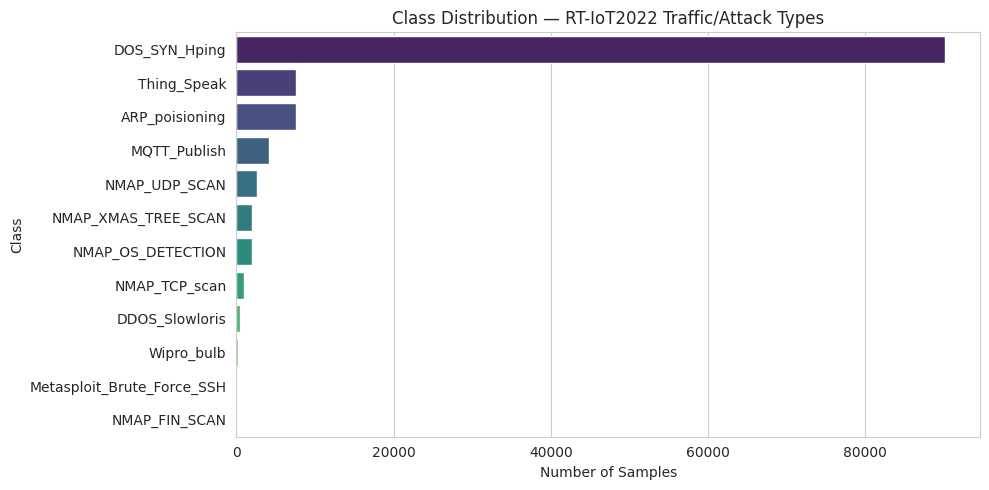

In [8]:
# Class distribution of the target variable
class_counts = df["target"].value_counts()
print(class_counts)

plt.figure(figsize=(10, 5))
sns.barplot(x=class_counts.values, y=class_counts.index, palette="viridis")
plt.title("Class Distribution — RT-IoT2022 Traffic/Attack Types")
plt.xlabel("Number of Samples")
plt.ylabel("Class")
plt.tight_layout()
plt.show()


In [9]:
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Largest class: {class_counts.idxmax()} ({class_counts.max()} samples)")
print(f"Smallest class: {class_counts.idxmin()} ({class_counts.min()} samples)")
print(f"Imbalance ratio (largest/smallest): {imbalance_ratio:.1f}x")
print("\n=> The dataset is imbalanced. This is why macro-averaged metrics (which weight "
      "every class equally) are reported alongside accuracy and weighted metrics.")


Largest class: DOS_SYN_Hping (90089 samples)
Smallest class: NMAP_FIN_SCAN (28 samples)
Imbalance ratio (largest/smallest): 3217.5x

=> The dataset is imbalanced. This is why macro-averaged metrics (which weight every class equally) are reported alongside accuracy and weighted metrics.


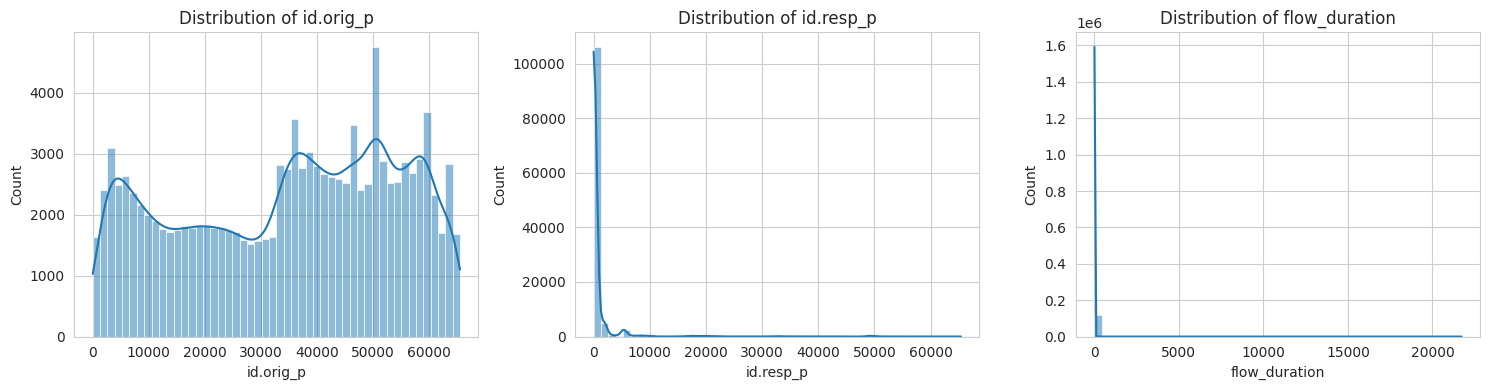

Features plotted: ['id.orig_p', 'id.resp_p', 'flow_duration']


In [10]:
# Feature distribution plots (at least 3 meaningful numeric features)
numeric_features = [c for c in num_cols if df[c].nunique() > 5][:3]
fig, axes = plt.subplots(1, len(numeric_features), figsize=(15, 4))
for ax, col in zip(axes, numeric_features):
    sns.histplot(df[col], bins=50, ax=ax, kde=True)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()
print("Features plotted:", numeric_features)


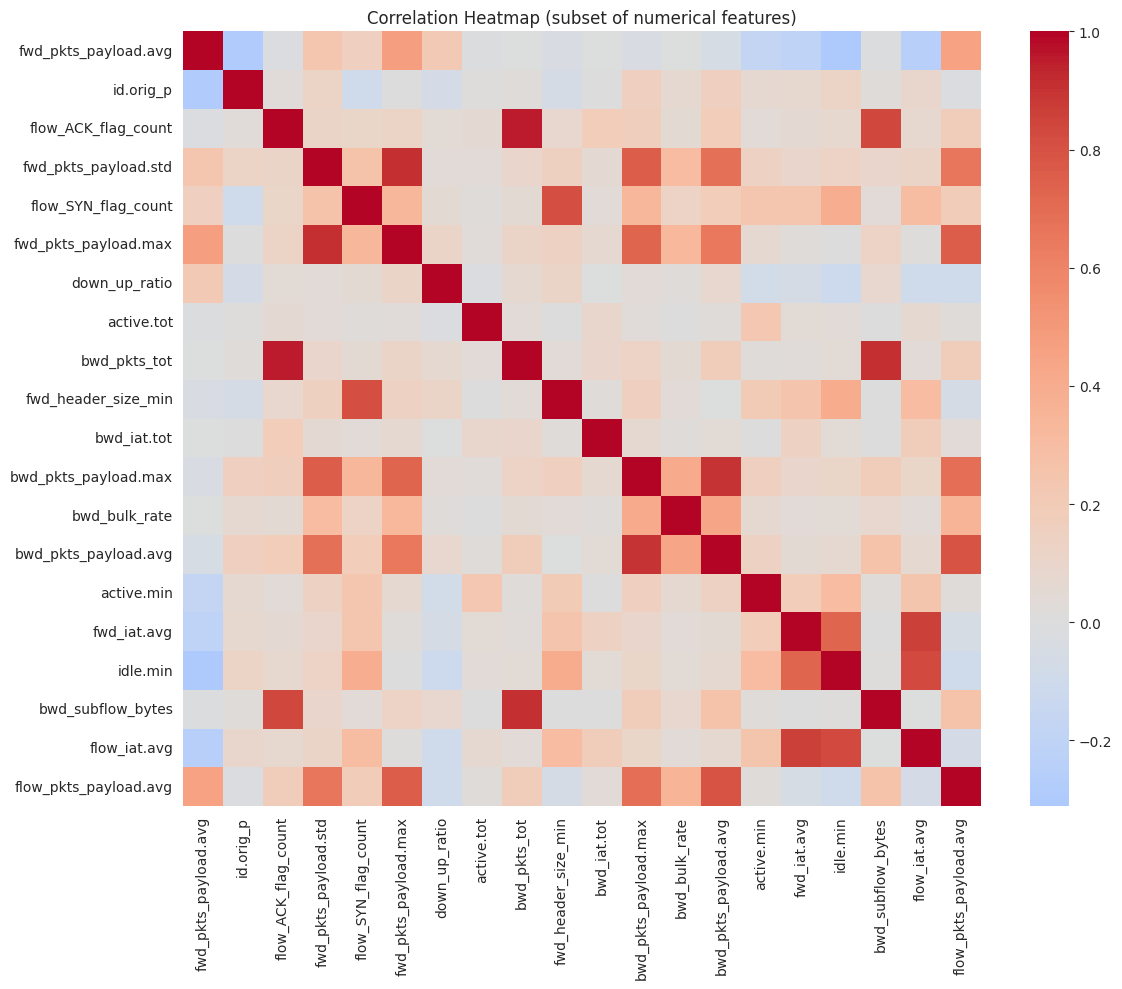

In [11]:
# Correlation heatmap for a subset of numerical features (full 84-feature heatmap is unreadable)
corr_subset = df[num_cols].sample(n=min(20, len(num_cols)), axis=1, random_state=RANDOM_SEED) \
    if len(num_cols) > 20 else df[num_cols]
plt.figure(figsize=(12, 10))
sns.heatmap(corr_subset.corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap (subset of numerical features)")
plt.tight_layout()
plt.show()


In [12]:
# Outlier check via IQR on a couple of key numeric features
for col in numeric_features:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {n_outliers} potential outliers ({n_outliers/len(df)*100:.2f}%)")

print("\n=> Outliers are expected in network-flow data (e.g. occasional very long "
      "connections or bursty packet rates) and often correspond to genuine attack "
      "behaviour rather than data errors, so they are NOT removed — doing so could "
      "delete real minority-class signal.")


id.orig_p: 0 potential outliers (0.00%)
id.resp_p: 27827 potential outliers (23.60%)
flow_duration: 18783 potential outliers (15.93%)

=> Outliers are expected in network-flow data (e.g. occasional very long connections or bursty packet rates) and often correspond to genuine attack behaviour rather than data errors, so they are NOT removed — doing so could delete real minority-class signal.


## 4. Preprocessing & Data Splitting
Encode categorical features, split BEFORE fitting any transformer, then scale
(fit on training data only) to avoid data leakage.


In [13]:
# Separate features / target
X = df.drop(columns=["target"])
y = df["target"]

# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print("Encoded classes:", dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))

# One-hot encode any remaining categorical feature columns (e.g. protocol/service)
if cat_cols:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=False)
print("Feature matrix shape after encoding:", X.shape)


Encoded classes: {'ARP_poisioning': 0, 'DDOS_Slowloris': 1, 'DOS_SYN_Hping': 2, 'MQTT_Publish': 3, 'Metasploit_Brute_Force_SSH': 4, 'NMAP_FIN_SCAN': 5, 'NMAP_OS_DETECTION': 6, 'NMAP_TCP_scan': 7, 'NMAP_UDP_SCAN': 8, 'NMAP_XMAS_TREE_SCAN': 9, 'Thing_Speak': 10, 'Wipro_bulb': 11}
Feature matrix shape after encoding: (117922, 94)


In [14]:
# 70/15/15 train/validation/test split (stratified to preserve class ratios)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.30, random_state=RANDOM_SEED, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED, stratify=y_temp
)

print("Train:", X_train.shape, " Validation:", X_val.shape, " Test:", X_test.shape)


Train: (82545, 94)  Validation: (17688, 94)  Test: (17689, 94)


In [15]:
# Feature scaling — fit ONLY on training data, then transform val/test (no leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete. Scaler was fit on X_train only.")


Scaling complete. Scaler was fit on X_train only.


## 5. Model Training

`class_weight="balanced"` is used where available to reduce bias toward majority classes.


In [16]:
# --- Model 1: Logistic Regression ---
log_reg = LogisticRegression(
    max_iter=1000, class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1
)
log_reg.fit(X_train_scaled, y_train)
print("Logistic Regression trained.")


Logistic Regression trained.


In [17]:
# --- Model 2: Random Forest ---
rf = RandomForestClassifier(
    n_estimators=200, max_depth=None, class_weight="balanced_subsample",
    random_state=RANDOM_SEED, n_jobs=-1
)
rf.fit(X_train_scaled, y_train)
print("Random Forest trained.")


Random Forest trained.


In [18]:
# --- Model 3: MLP Classifier (trained epoch-by-epoch to record train/val curves) ---
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    max_iter=1,
    warm_start=True,   # keep weights between .fit() calls -> manual epoch loop
    random_state=RANDOM_SEED
)

N_EPOCHS = 30
history = {"train_loss": [], "val_loss": [],
           "train_acc": [], "val_acc": [],
           "train_f1": [], "val_f1": [],
           "train_precision": [], "val_precision": [],
           "train_recall": [], "val_recall": []}

for epoch in range(N_EPOCHS):
    mlp.fit(X_train_scaled, y_train)  # runs exactly 1 more epoch because max_iter=1, warm_start=True

    train_pred = mlp.predict(X_train_scaled)
    val_pred = mlp.predict(X_val_scaled)

    history["train_loss"].append(mlp.loss_)
    # sklearn MLP doesn't expose a separate val loss, so validation loss is approximated
    # via log_loss on validation predictions' probabilities
    from sklearn.metrics import log_loss
    val_proba = mlp.predict_proba(X_val_scaled)
    history["val_loss"].append(log_loss(y_val, val_proba, labels=np.arange(len(label_encoder.classes_))))

    history["train_acc"].append(accuracy_score(y_train, train_pred))
    history["val_acc"].append(accuracy_score(y_val, val_pred))
    history["train_f1"].append(f1_score(y_train, train_pred, average="macro", zero_division=0))
    history["val_f1"].append(f1_score(y_val, val_pred, average="macro", zero_division=0))
    history["train_precision"].append(precision_score(y_train, train_pred, average="macro", zero_division=0))
    history["val_precision"].append(precision_score(y_val, val_pred, average="macro", zero_division=0))
    history["train_recall"].append(recall_score(y_train, train_pred, average="macro", zero_division=0))
    history["val_recall"].append(recall_score(y_val, val_pred, average="macro", zero_division=0))

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{N_EPOCHS} - train_loss: {history['train_loss'][-1]:.4f} "
              f"- val_acc: {history['val_acc'][-1]:.4f} - val_macro_f1: {history['val_f1'][-1]:.4f}")

print("\nMLP training complete.")


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Epoch 1/30 - train_loss: 0.1487 - val_acc: 0.9839 - val_macro_f1: 0.8597


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Epoch 5/30 - train_loss: 0.0196 - val_acc: 0.9943 - val_macro_f1: 0.9551


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691

...

Epoch 20/30 - train_loss: 0.0113 - val_acc: 0.9943 - val_macro_f1: 0.9612


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691

Epoch 25/30 - train_loss: 0.0116 - val_acc: 0.9934 - val_macro_f1: 0.9517


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691

Epoch 30/30 - train_loss: 0.0105 - val_acc: 0.9946 - val_macro_f1: 0.9621

MLP training complete.


### Epoch-wise training curves (MLP)

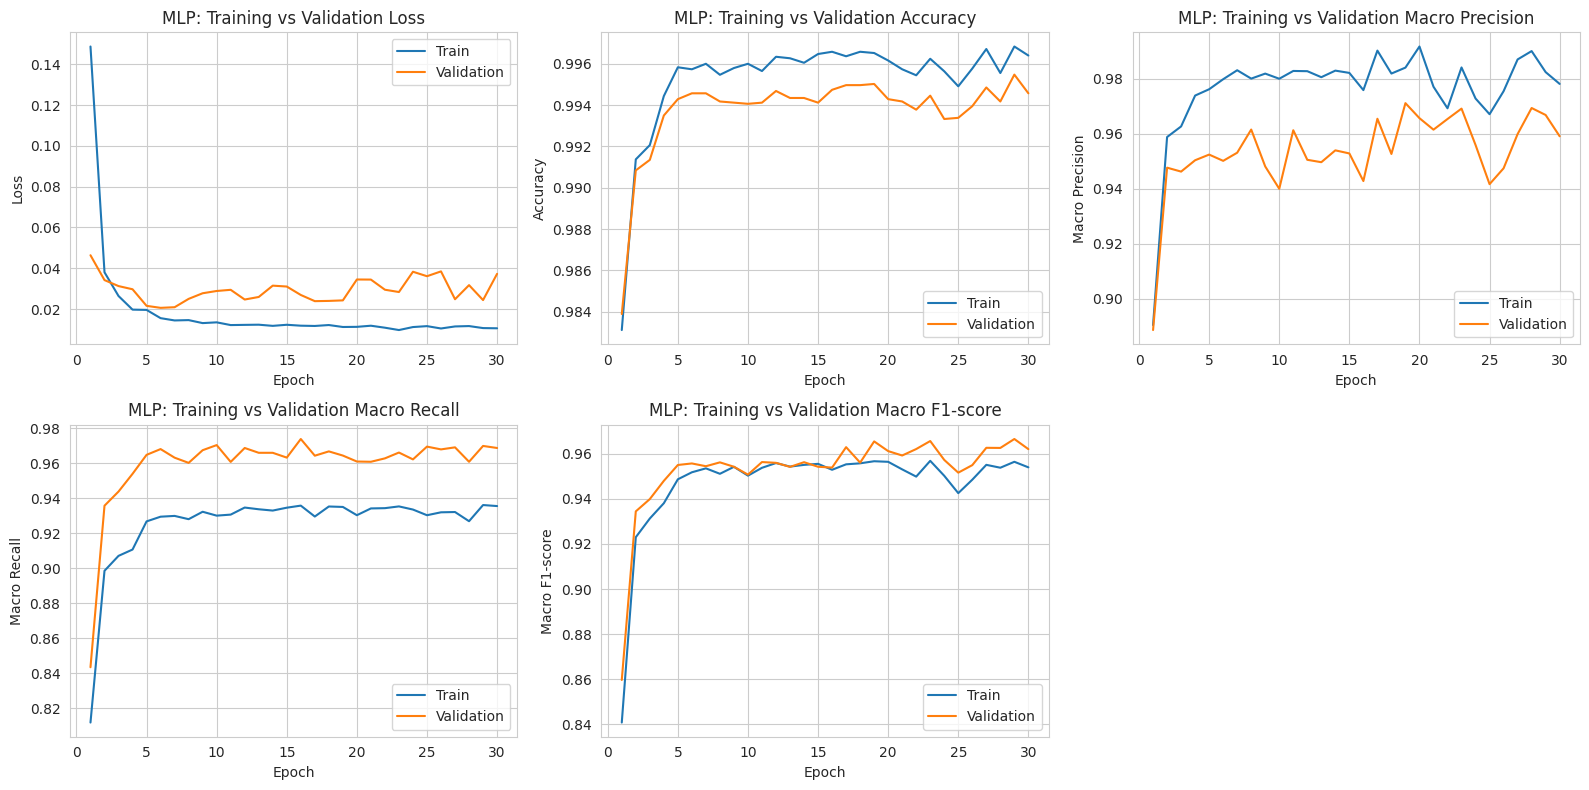

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
metric_pairs = [
    ("train_loss", "val_loss", "Loss"),
    ("train_acc", "val_acc", "Accuracy"),
    ("train_precision", "val_precision", "Macro Precision"),
    ("train_recall", "val_recall", "Macro Recall"),
    ("train_f1", "val_f1", "Macro F1-score"),
]
for ax, (train_key, val_key, title) in zip(axes.flat, metric_pairs):
    ax.plot(range(1, N_EPOCHS + 1), history[train_key], label="Train")
    ax.plot(range(1, N_EPOCHS + 1), history[val_key], label="Validation")
    ax.set_title(f"MLP: Training vs Validation {title}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.legend()
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()


## 6. Model Evaluation & Visualization
All three models are evaluated on the **held-out test set** using Accuracy, Macro/Weighted
Precision, Recall, F1-score, plus confusion matrices and classification reports.


In [20]:
models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf,
    "MLP Classifier": mlp,
}

results = []
predictions = {}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro Precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "Weighted Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Weighted Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "Weighted F1": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    })

results_df = pd.DataFrame(results).set_index("Model")
results_df.round(4)


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
Model,,,,,,,
Logistic Regression,0.9878,0.7840,0.9562,0.8197,0.9909,0.9878,0.9889
Random Forest,0.9985,0.9941,0.9707,0.9814,0.9985,0.9985,0.9985
MLP Classifier,0.9956,0.9589,0.9728,0.9640,0.9957,0.9956,0.9956


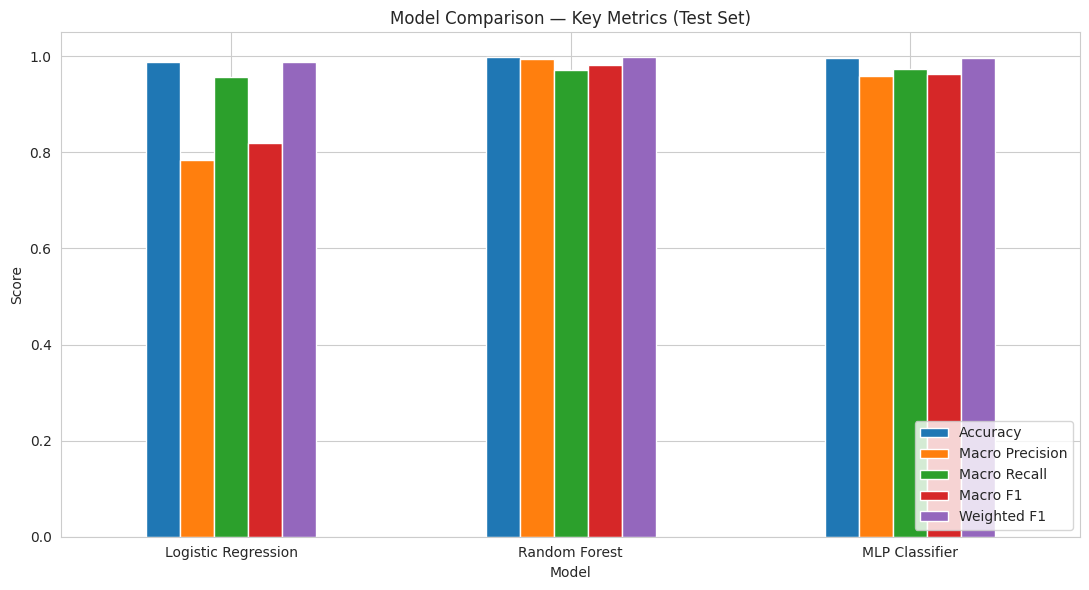

In [21]:
# Metric comparison bar chart
results_df[["Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Weighted F1"]].plot(
    kind="bar", figsize=(11, 6), rot=0
)
plt.title("Model Comparison — Key Metrics (Test Set)")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


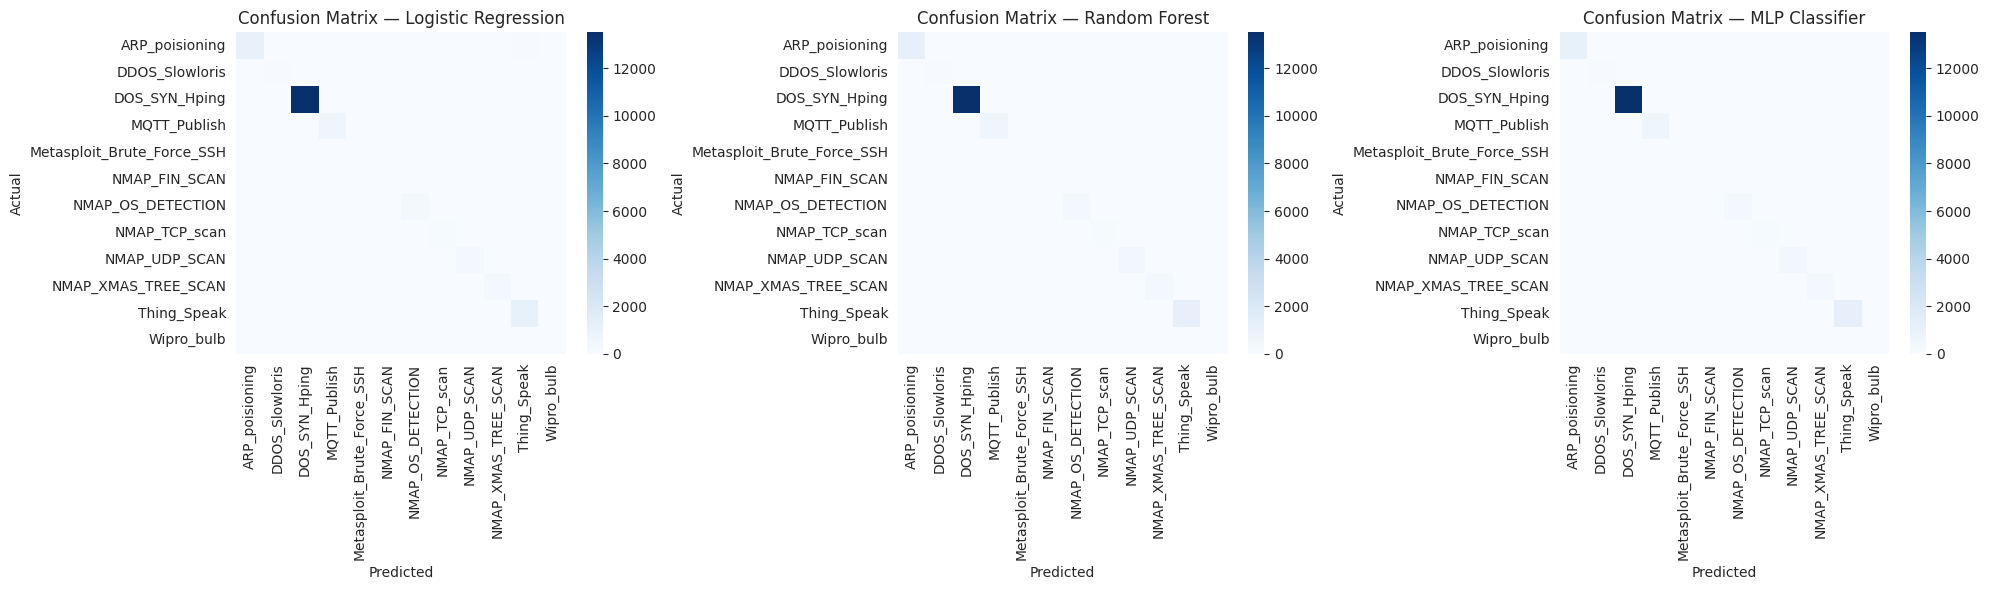

In [22]:
# Confusion matrix heatmaps for all three models
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=False, cmap="Blues", ax=ax,
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    ax.set_title(f"Confusion Matrix — {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.tick_params(axis="x", rotation=90)
    ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()


In [23]:
# Full classification reports
for name, y_pred in predictions.items():
    print(f"\n{'='*20} {name} {'='*20}")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))



==================== Logistic Regression ====================
                            precision    recall  f1-score   support

            ARP_poisioning       0.96      0.90      0.93      1144
            DDOS_Slowloris       0.70      0.97      0.82        80
             DOS_SYN_Hping       1.00      1.00      1.00     13514
              MQTT_Publish       1.00      1.00      1.00       622
Metasploit_Brute_Force_SSH       0.16      0.80      0.27         5
             NMAP_FIN_SCAN       0.17      1.00      0.29         4
         NMAP_OS_DETECTION       1.00      1.00      1.00       300
             NMAP_TCP_scan       0.99      1.00      0.99       150
             NMAP_UDP_SCAN       1.00      0.91      0.96       388
       NMAP_XMAS_TREE_SCAN       1.00      1.00      1.00       301
               Thing_Speak       0.95      0.94      0.95      1148
                Wipro_bulb       0.49      0.94      0.65        33

                  accuracy                         

## 7. Result Summary & Best Model Selection

In [24]:
print("Final metric comparison (Test set):\n")
print(results_df.round(4))

print("\nBest model per metric:")
for metric in results_df.columns:
    best_model = results_df[metric].idxmax()
    print(f"  {metric}: {best_model} ({results_df[metric].max():.4f})")


Final metric comparison (Test set):

                     Accuracy  Macro Precision  Macro Recall  Macro F1  \
Model                                                                    
Logistic Regression    0.9878           0.7840        0.9562    0.8197   
Random Forest          0.9985           0.9941        0.9707    0.9814   
MLP Classifier         0.9956           0.9589        0.9728    0.9640   

                     Weighted Precision  Weighted Recall  Weighted F1  
Model                                                                  
Logistic Regression              0.9909           0.9878       0.9889  
Random Forest                    0.9985           0.9985       0.9985  
MLP Classifier                   0.9957           0.9956       0.9956  

Best model per metric:
  Accuracy: Random Forest (0.9985)
  Macro Precision: Random Forest (0.9941)
  Macro Recall: MLP Classifier (0.9728)
  Macro F1: Random Forest (0.9814)
  Weighted Precision: Random Forest (0.9985)
  Weighted 

In [25]:
# Balanced reasoning: rank models by average rank across the 4 macro-level metrics
# (macro metrics matter most here because of class imbalance) rather than accuracy alone.
ranking_metrics = ["Macro Precision", "Macro Recall", "Macro F1", "Weighted F1"]
ranks = results_df[ranking_metrics].rank(ascending=False)
avg_rank = ranks.mean(axis=1).sort_values()
print("Average rank across macro-level metrics (lower = better):")
print(avg_rank)

best_model_name = avg_rank.idxmin()
print(f"\n>>> SELECTED BEST MODEL: {best_model_name} <<<")
print("\nClassification report of the selected model:")
print(classification_report(y_test, predictions[best_model_name],
                             target_names=label_encoder.classes_, zero_division=0))


Average rank across macro-level metrics (lower = better):
Model
Random Forest          1.25
MLP Classifier         1.75
Logistic Regression    3.00
dtype: float64

>>> SELECTED BEST MODEL: Random Forest <<<

Classification report of the selected model:
                            precision    recall  f1-score   support

            ARP_poisioning       0.99      0.99      0.99      1144
            DDOS_Slowloris       0.99      0.96      0.97        80
             DOS_SYN_Hping       1.00      1.00      1.00     13514
              MQTT_Publish       1.00      1.00      1.00       622
Metasploit_Brute_Force_SSH       1.00      0.80      0.89         5
             NMAP_FIN_SCAN       1.00      1.00      1.00         4
         NMAP_OS_DETECTION       1.00      1.00      1.00       300
             NMAP_TCP_scan       1.00      1.00      1.00       150
             NMAP_UDP_SCAN       0.99      0.99      0.99       388
       NMAP_XMAS_TREE_SCAN       1.00      1.00      1.00       30

## 8. Discussion & Limitations
- **Class imbalance:** RT-IoT2022 has a [DOS_SYN_Hping] imbalance ratio between the largest and
  smallest class. This inflates raw accuracy relative to macro-F1, since majority classes
  dominate the accuracy score. Macro metrics were therefore reported alongside accuracy.
- **Model limitations:**
  - *Logistic Regression* assumes linear decision boundaries and underperforms on classes
    whose separation is non-linear in the raw feature space.
  - *Random Forest* handles non-linearity and class imbalance well but can overfit rare
    classes with very few training examples and offers less interpretability at scale.
  - *MLP* needs more data/epochs to fully converge on minority classes and is sensitive to
    feature scaling and hyperparameter choices (hidden layer size, learning rate).
- **Generalization risk:** the dataset was captured from a specific IoT testbed
  (ThingSpeak-LED, Wipro-Bulb, MQTT-Temp devices); performance may not transfer directly to
  other IoT device types, network topologies, or previously unseen attack variants (zero-day
  attacks) not represented in the 12 classes.
- **Future improvements:** techniques such as SMOTE/class-weighted resampling, more
  extensive hyperparameter tuning (grid/random search on the validation set), and ensembling
  the three models could further improve minority-class recall.
